In [ ]:
# Cell 1 – Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import pyxlsb

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "#f8f9fa"
plt.rcParams["axes.grid"]        = True
plt.rcParams["grid.alpha"]       = 0.3

CELL_COL = "CO_DN"
RAW_FILE = "../data/4G raw KPI Cell wise17th_June'26.xlsb"

def short_cell_name(co_dn):
    """
    Input : PLMN-PLMN/MRBTS-803406/LNBTS-803406/LNCEL-41
    Output: LNBTS-803406_LNCEL-41
    """
    parts = str(co_dn).split("/")
    if len(parts) >= 2:
        return f"{parts[-2]}_{parts[-1]}"
    return str(co_dn)

def safe_float(value):
    if value is None:
        return np.nan
    try:
        f = float(value)
        return np.nan if np.isinf(f) else f
    except (ValueError, TypeError):
        return np.nan

KPI_CONFIG = [
    {
        "col"      : "ERAB Drop Rate_Radio_Nokia_VeMr",
        "label"    : "Drop Rate",
        "threshold": 0.5,
        "direction": "high",
        "weight"   : 30,
        "unit"     : "%",
        "color"    : "#C00000",
    },
    {
        "col"      : "E2E Call Setup Success Rate_Nokia_VeMr",
        "label"    : "E2E CSSR",
        "threshold": 99.5,
        "direction": "low",
        "weight"   : 25,
        "unit"     : "%",
        "color"    : "#2E75B6",
    },
    {
        "col"      : "VoLTE Call Setup Success Rate_Nokia_VeMr",
        "label"    : "VoLTE CSSR",
        "threshold": 99.5,
        "direction": "low",
        "weight"   : 20,
        "unit"     : "%",
        "color"    : "#70AD47",
    },
    {
        "col"      : "Average CQI_Nokia_VeMr",
        "label"    : "CQI",
        "threshold": 7.0,
        "direction": "low",
        "weight"   : 15,
        "unit"     : "", 
        "color"    : "#FF8C00",
    },
    {
        "col"      : "Nokia_LTE_DL_User_Throughput_Mbps",
        "label"    : "Avg Thpr",
        "threshold": 3.0,
        "direction": "low",
        "weight"   : 10,
        "unit"     : "Mbps",
        "color"    : "#FFA500",
    },
]

In [6]:
# Cell 2 – Load all outputs from previous notebooks

# Sheet names
with pyxlsb.open_workbook(RAW_FILE) as wb:
    sheet_names = wb.sheets
    KPI_COLS = [
    "ERAB Drop Rate_Radio_Nokia_VeMr",
    "E2E Call Setup Success Rate_Nokia_VeMr",
    "VoLTE Call Setup Success Rate_Nokia_VeMr",
    "Average CQI_Nokia_VeMr",
    "Nokia_LTE_DL_User_Throughput_Mbps",
]

# Master cleaned data
df = pd.read_csv("../data/cleaned_master_data.csv")
if "Short_Cell" not in df.columns:
    df["Short_Cell"] = df[CELL_COL].apply(short_cell_name)
for col in KPI_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Root cause labelled data
rc_df = pd.read_csv("../outputs/root_cause_labelled.csv")
if "Short_Cell" not in rc_df.columns:
    rc_df["Short_Cell"] = rc_df[CELL_COL].apply(short_cell_name)

# Cell-level anomaly results
anomaly_df = pd.read_csv("../outputs/cell_anomaly_results.csv")

# Priority cells
priority_df = pd.read_csv("../outputs/priority_cells_with_rc.csv")

# Root cause frequency
rc_freq_df = pd.read_csv("../outputs/root_cause_frequency.csv")

# Day index map
day_order = {day: i for i, day in enumerate(sheet_names)}
df["Day_Index"]    = df["Day"].map(day_order)
rc_df["Day_Index"] = rc_df["Day"].map(day_order)

print(f"Master data       : {df.shape}")
print(f"Root cause data   : {rc_df.shape}")
print(f"Anomaly results   : {anomaly_df.shape}")
print(f"Priority cells    : {priority_df.shape}")
print(f"Days              : {len(sheet_names)}")
print(f"Unique cells      : {df['Short_Cell'].nunique()}")

Master data       : (842125, 98)
Root cause data   : (842125, 12)
Anomaly results   : (51359, 10)
Priority cells    : (2315, 8)
Days              : 17
Unique cells      : 51359


KeyError: 'color'

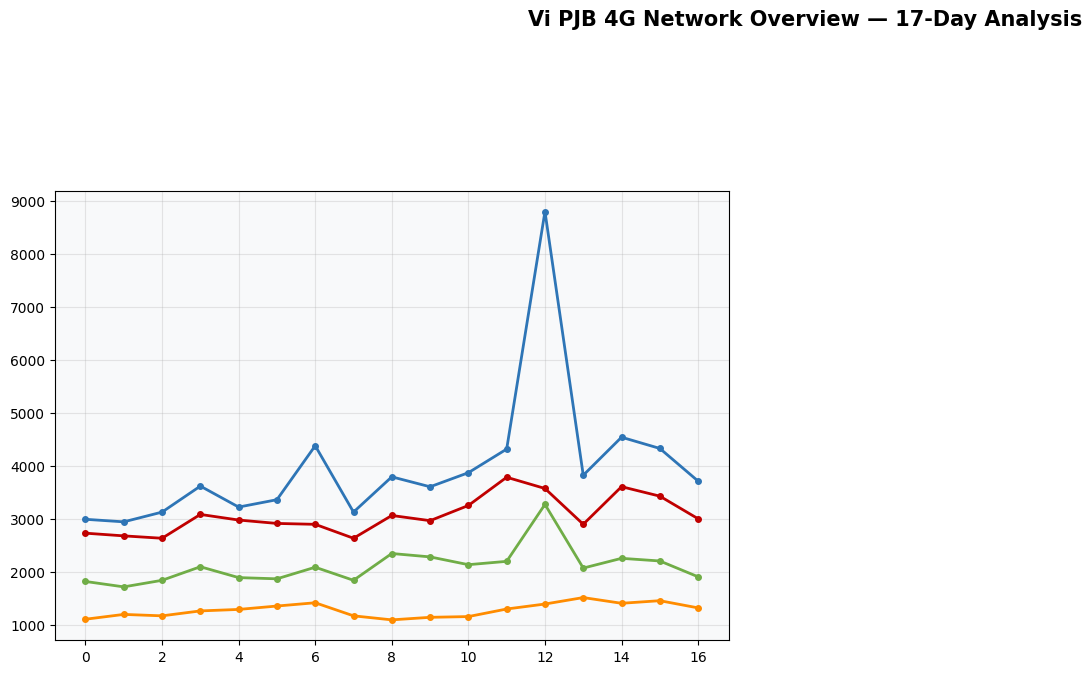

In [7]:
# Cell 3 – Network overview: 4-panel summary chart

fig = plt.figure(figsize=(20, 14))
fig.suptitle("Vi PJB 4G Network Overview — 17-Day Analysis",
             fontsize=15, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# ── Plot 1: Daily fail count trend per KPI ──
ax1 = fig.add_subplot(gs[0, 0])
for cfg in KPI_CONFIG:
    col = cfg["col"]
    if col not in df.columns:
        continue
    numeric = pd.to_numeric(df[col], errors="coerce")
    if cfg["direction"] == "high":
        mask = numeric > cfg["threshold"]
    else:
        mask = numeric < cfg["threshold"]
    daily_fails = df.assign(_fail=mask.astype(int)).groupby(
        "Day")["_fail"].sum().reindex(sheet_names).fillna(0)
    ax1.plot(
        range(len(sheet_names)),
        daily_fails.values,
        marker="o", markersize=4,
        linewidth=2, label=cfg["label"],
        color=cfg["color"]
    )

ax1.set_xticks(range(len(sheet_names)))
ax1.set_xticklabels([s[:10] for s in sheet_names],
                    rotation=45, ha="right", fontsize=7)
ax1.set_title("Daily KPI Failure Count per KPI",
              fontweight="bold")
ax1.set_ylabel("Cells Failing Threshold")
ax1.legend(fontsize=8)

# ── Plot 2: Severity distribution pie ──
ax2  = fig.add_subplot(gs[0, 1])
sevs = rc_df["Severity"].value_counts()
sev_order  = ["Critical", "High", "Medium", "Low", "None"]
sev_colors = {
    "Critical": "#C00000", "High": "#FF8C00",
    "Medium"  : "#FFD700", "Low" : "#70AD47",
    "None"    : "#BFBFBF"
}
sevs = sevs.reindex([s for s in sev_order if s in sevs.index])
ax2.pie(
    sevs.values,
    labels    = sevs.index,
    colors    = [sev_colors[s] for s in sevs.index],
    autopct   = "%1.1f%%",
    startangle= 90,
    wedgeprops= dict(edgecolor="white", linewidth=1.5)
)
ax2.set_title("Overall Severity Distribution\n(All Cells, All Days)",
              fontweight="bold")

# ── Plot 3: Root cause frequency ──
ax3 = fig.add_subplot(gs[1, 0])
rc_colors = ["#C00000" if "High" in rc else "#2E75B6"
             for rc in rc_freq_df["Root Cause"]]
bars = ax3.barh(
    rc_freq_df["Root Cause"][::-1],
    rc_freq_df["Frequency"][::-1],
    color=rc_colors[::-1], edgecolor="white"
)
for bar, val in zip(bars, rc_freq_df["Frequency"][::-1]):
    ax3.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va="center", fontsize=8)
ax3.set_title("Root Cause Frequency (All Days)",
              fontweight="bold")
ax3.set_xlabel("Number of Occurrences")

# ── Plot 4: Anomaly score distribution ──
ax4 = fig.add_subplot(gs[1, 1])
if "anomaly_score" in anomaly_df.columns and \
   "anomaly_flag" in anomaly_df.columns:
    normal  = anomaly_df[anomaly_df["anomaly_flag"] ==  1]["anomaly_score"]
    outlier = anomaly_df[anomaly_df["anomaly_flag"] == -1]["anomaly_score"]
    ax4.hist(normal,  bins=25, color="#2E75B6", alpha=0.7,
             label="Normal",  edgecolor="white")
    ax4.hist(outlier, bins=25, color="#C00000", alpha=0.7,
             label="Outlier", edgecolor="white")
    ax4.set_title("Isolation Forest Anomaly Score Distribution",
                  fontweight="bold")
    ax4.set_xlabel("Anomaly Score")
    ax4.set_ylabel("Number of Cells")
    ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/viz_network_overview.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/viz_network_overview.png")

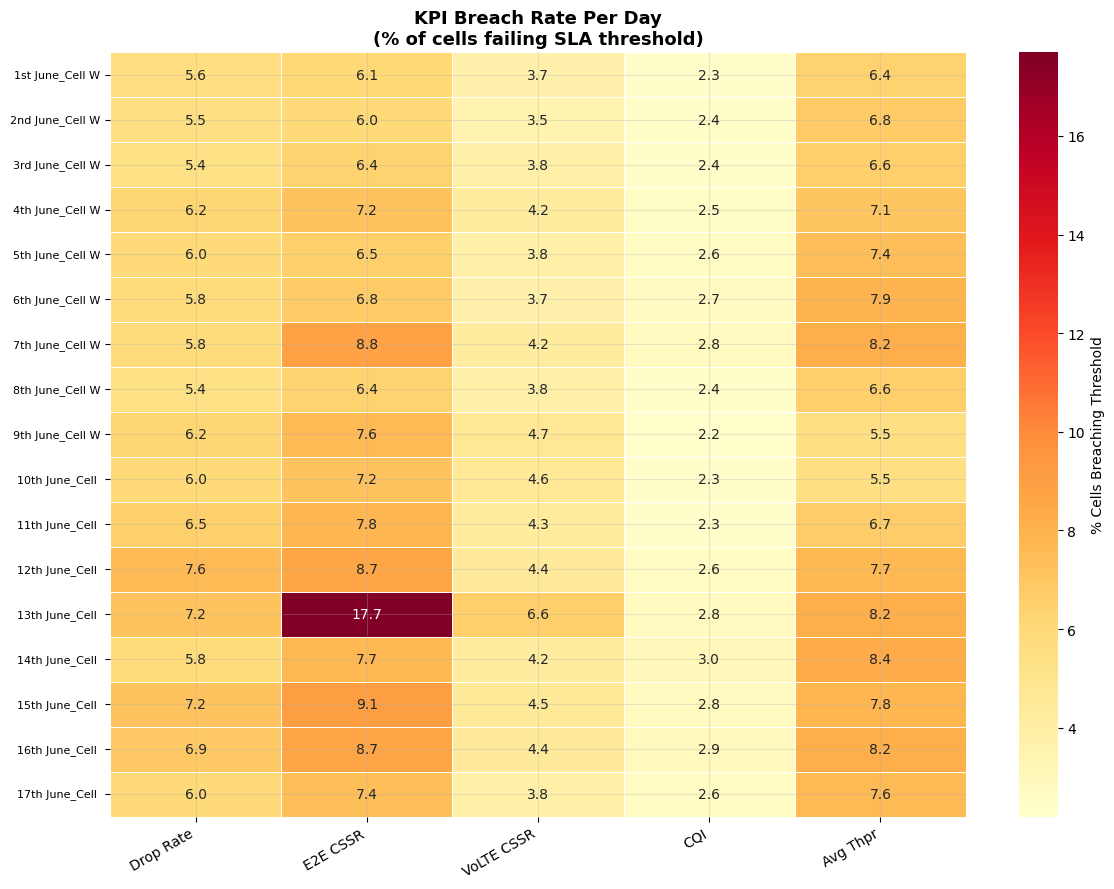

✅ Saved → outputs/viz_breach_heatmap.png


In [8]:
# Cell 4 – KPI breach rate heatmap: % cells failing per day per KPI

kpi_present  = [c for c in KPI_COLS if c in df.columns]
kpi_labels   = [cfg["label"] for cfg in KPI_CONFIG
                if cfg["col"] in kpi_present]

breach_matrix = pd.DataFrame(
    index   = sheet_names,
    columns = kpi_labels,
    dtype   = float
)

for cfg in KPI_CONFIG:
    col = cfg["col"]
    if col not in df.columns:
        continue
    for day in sheet_names:
        day_data = pd.to_numeric(
            df[df["Day"] == day][col], errors="coerce"
        ).dropna()
        if len(day_data) == 0:
            breach_matrix.loc[day, cfg["label"]] = 0
            continue
        if cfg["direction"] == "high":
            pct = (day_data > cfg["threshold"]).mean() * 100
        else:
            pct = (day_data < cfg["threshold"]).mean() * 100
        breach_matrix.loc[day, cfg["label"]] = round(pct, 1)

breach_matrix = breach_matrix.apply(pd.to_numeric, errors="coerce")

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    breach_matrix,
    annot     = True,
    fmt       = ".1f",
    cmap      = "YlOrRd",
    linewidths= 0.5,
    ax        = ax,
    cbar_kws  = {"label": "% Cells Breaching Threshold"}
)
ax.set_title(
    "KPI Breach Rate Per Day\n"
    "(% of cells failing SLA threshold)",
    fontweight="bold", fontsize=13
)
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(
    [s[:15] for s in sheet_names],
    rotation=0, fontsize=8
)
plt.tight_layout()
plt.savefig("../outputs/viz_breach_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/viz_breach_heatmap.png")

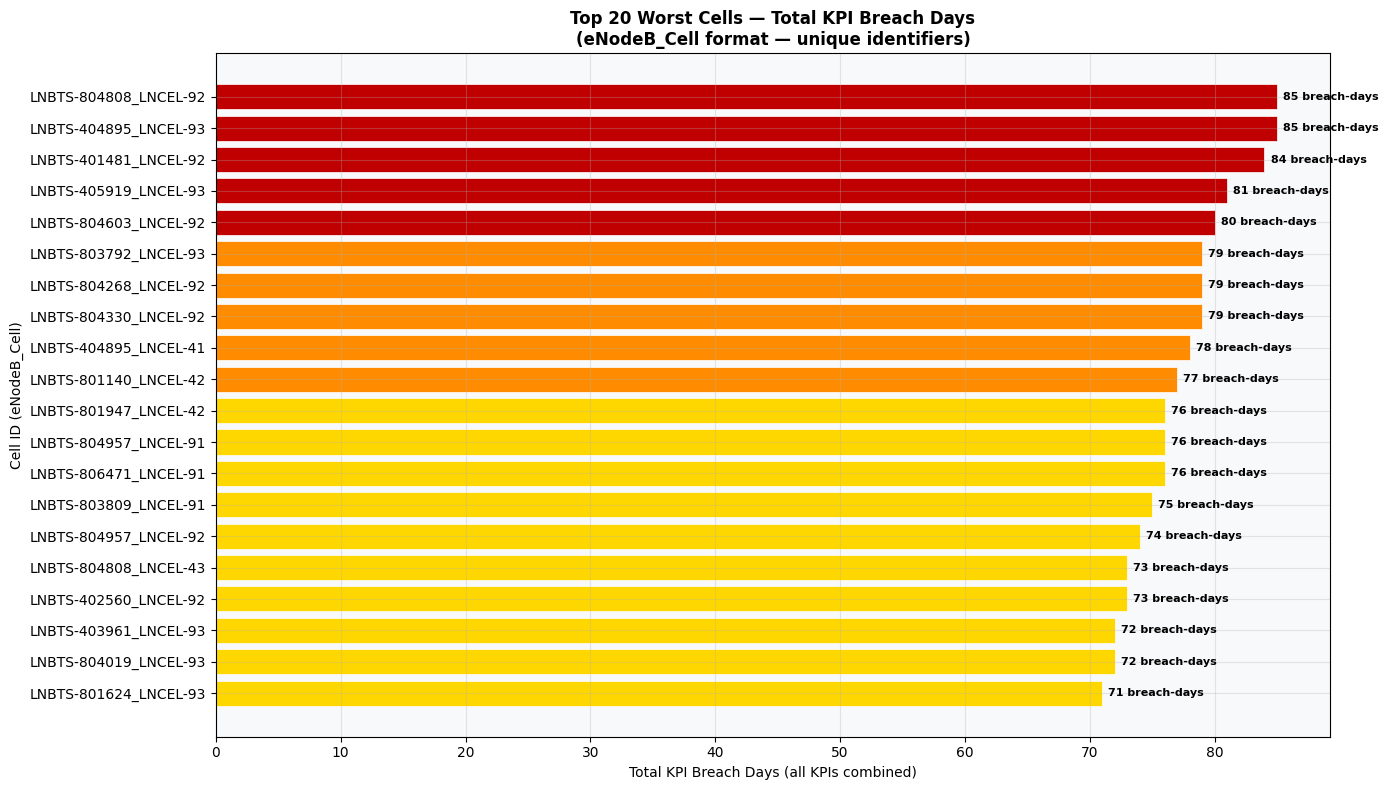

✅ Saved → outputs/viz_worst_cells_overall.png


In [9]:
# Cell 5 – Top 20 worst cells across all KPIs combined

# Total breach days across all KPIs per cell
kpi_breach_cols = []
for cfg in KPI_CONFIG:
    col = cfg["col"]
    if col not in df.columns:
        continue
    numeric = pd.to_numeric(df[col], errors="coerce")
    if cfg["direction"] == "high":
        mask = (numeric > cfg["threshold"]).astype(int)
    else:
        mask = (numeric < cfg["threshold"]).astype(int)
    breach_col = f"_breach_{cfg['label']}"
    df[breach_col] = mask.fillna(0)
    kpi_breach_cols.append(breach_col)

df["_total_breach"] = df[kpi_breach_cols].sum(axis=1)

worst_cells = (
    df.groupby("Short_Cell")["_total_breach"]
    .sum()
    .reset_index()
    .sort_values("_total_breach", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(14, 8))
colors  = [
    "#C00000" if v > worst_cells["_total_breach"].quantile(0.75)
    else "#FF8C00" if v > worst_cells["_total_breach"].quantile(0.5)
    else "#FFD700"
    for v in worst_cells["_total_breach"]
]

bars = ax.barh(
    worst_cells["Short_Cell"][::-1],
    worst_cells["_total_breach"][::-1],
    color=colors[::-1], edgecolor="white", linewidth=0.5
)
for bar, val in zip(bars, worst_cells["_total_breach"][::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{int(val)} breach-days",
        va="center", fontsize=8, fontweight="bold"
    )

ax.set_title(
    "Top 20 Worst Cells — Total KPI Breach Days\n"
    "(eNodeB_Cell format — unique identifiers)",
    fontweight="bold", fontsize=12
)
ax.set_xlabel("Total KPI Breach Days (all KPIs combined)")
ax.set_ylabel("Cell ID (eNodeB_Cell)")
plt.tight_layout()
plt.savefig("../outputs/viz_worst_cells_overall.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/viz_worst_cells_overall.png")

# Cleanup temp columns
df.drop(columns=kpi_breach_cols + ["_total_breach"],
        inplace=True, errors="ignore")

In [10]:
# Cell 6 – Generate Daily Outlier Report Excel
# One sheet per day, worst cells at top
# Uses Short_Cell as identifier

OUTPUT_EXCEL = "../outputs/Daily_Outlier_Cell_Report.xlsx"

THRESHOLDS = {cfg["col"]: (cfg["direction"], cfg["threshold"])
              for cfg in KPI_CONFIG}

# Styles
TTL_FILL  = PatternFill("solid", fgColor="0D2137")
TTL_FONT  = Font(bold=True, color="FFFFFF", name="Arial", size=12)
HDR_FILL  = PatternFill("solid", fgColor="1F4E79")
HDR_FONT  = Font(bold=True, color="FFFFFF", name="Arial", size=10)
ALT_FILL  = PatternFill("solid", fgColor="D6E4F0")
CRIT_FILL = PatternFill("solid", fgColor="FFDDC1")
BODY_FONT = Font(name="Arial", size=9)
RED_FONT  = Font(name="Arial", size=9, color="C00000", bold=True)
THIN      = Side(style="thin", color="BFBFBF")
BORDER    = Border(left=THIN, right=THIN, top=THIN, bottom=THIN)
CENTER    = Alignment(horizontal="center", vertical="center",
                      wrap_text=True)
LEFT      = Alignment(horizontal="left", vertical="center",
                      wrap_text=True)

def write_title_header(ws, title, headers):
    ncols = len(headers)
    ws.append([title] + [""] * (ncols - 1))
    ws.merge_cells(f"A1:{get_column_letter(ncols)}1")
    ws["A1"].fill = TTL_FILL; ws["A1"].font = TTL_FONT
    ws["A1"].alignment = CENTER; ws["A1"].border = BORDER
    ws.append(headers)
    for cell in ws[2]:
        cell.fill = HDR_FILL; cell.font = HDR_FONT
        cell.alignment = CENTER; cell.border = BORDER
    ws.row_dimensions[1].height = 22
    ws.row_dimensions[2].height = 28

def apply_base_style(ws, start_row, end_row, ncols):
    for i in range(start_row, end_row + 1):
        fill = ALT_FILL if i % 2 == 0 else None
        for j in range(1, ncols + 1):
            c = ws.cell(row=i, column=j)
            c.font = BODY_FONT; c.border = BORDER
            c.alignment = LEFT if j == 1 else CENTER
            if fill: c.fill = fill

wb  = Workbook()
wb.remove(wb.active)

# ── Summary sheet ──
print("Writing Summary sheet...")
sw = wb.create_sheet("Summary", 0)
write_title_header(sw,
    "Daily Outlier Summary — Vi PJB 4G",
    ["Day", "Total Cells", "Outlier Cells",
     "Outlier %", "Cells Failing ≥3 KPIs", "Top Root Cause"]
)

summary_rows = []

# ── Per-day sheets ──
kpi_present  = [c for c in KPI_COLS if c in rc_df.columns]
kpi_labels_d = [cfg["label"] for cfg in KPI_CONFIG
                if cfg["col"] in kpi_present]

DISPLAY_COLS = (
    ["Short_Cell"] + kpi_present +
    ["fail_count", "Root_Cause"]
)
HEADERS = (
    ["Cell ID (eNodeB_Cell)"] +
    [f"{cfg['label']} ({'≤' if cfg['direction']=='high' else '≥'}"
     f"{cfg['threshold']}{cfg['unit']})"
     for cfg in KPI_CONFIG if cfg["col"] in kpi_present] +
    ["Fail Count", "Root Cause"]
)

# Pre-compute breach arrays per KPI
breach_arrays = {}
for cfg in KPI_CONFIG:
    col = cfg["col"]
    if col not in rc_df.columns:
        continue
    numeric = pd.to_numeric(rc_df[col], errors="coerce").values
    if cfg["direction"] == "high":
        breach_arrays[col] = numeric > cfg["threshold"]
    else:
        breach_arrays[col] = numeric < cfg["threshold"]

kpi_col_indices = {
    cfg["col"]: DISPLAY_COLS.index(cfg["col"]) + 1
    for cfg in KPI_CONFIG
    if cfg["col"] in DISPLAY_COLS
}

import re
from collections import Counter

for sheet in sheet_names:
    print(f"  Writing: {sheet[:35]}")
    day_df = rc_df[rc_df["Day"] == sheet].copy()
    if day_df.empty:
        continue

    # Only cells with at least 1 KPI fail
    outliers = day_df[day_df["fail_count"] > 0].sort_values(
        ["fail_count", "Root_Cause"], ascending=[False, True]
    ).reset_index(drop=True)

    if outliers.empty:
        continue

    # Pre-compute breach arrays for this day
    day_breach = {}
    for cfg in KPI_CONFIG:
        col = cfg["col"]
        if col not in outliers.columns:
            continue
        numeric = pd.to_numeric(outliers[col], errors="coerce").values
        if cfg["direction"] == "high":
            day_breach[col] = numeric > cfg["threshold"]
        else:
            day_breach[col] = numeric < cfg["threshold"]

    safe  = sheet[:31].replace("/", "-").replace(":", "-")
    ws    = wb.create_sheet(title=safe)
    ncols = len(DISPLAY_COLS)
    write_title_header(
        ws, f"Outlier Cells — {sheet}", HEADERS
    )

    # Write all rows
    for _, row in outliers[DISPLAY_COLS].iterrows():
        row_vals = []
        for c in DISPLAY_COLS:
            v = row[c] if c in row.index else ""
            if hasattr(v, "item"):
                v = v.item()
            row_vals.append(v)
        ws.append(row_vals)

    # Base styling
    apply_base_style(ws, 3, 3 + len(outliers) - 1, ncols)

    # Targeted overrides
    for i, (idx_pos, (_, row)) in enumerate(
        zip(range(3, 3 + len(outliers)), outliers.iterrows())
    ):
        row_i = i + 3 - (i - (i - 0))  # = i + 3
        row_i = 3 + i

        # Critical row highlight
        if row.get("fail_count", 0) >= 3:
            for j in range(1, ncols + 1):
                ws.cell(row=row_i, column=j).fill = CRIT_FILL

        # Red font for breached KPI values
        for cfg in KPI_CONFIG:
            col = cfg["col"]
            if col not in DISPLAY_COLS or col not in day_breach:
                continue
            if day_breach[col][i]:
                col_idx = DISPLAY_COLS.index(col) + 1
                ws.cell(row=row_i, column=col_idx).font = RED_FONT

    ws.column_dimensions["A"].width = 28
    for idx in range(2, ncols + 1):
        ws.column_dimensions[get_column_letter(idx)].width = 16
    ws.freeze_panes = "A3"

    # Summary row
    total     = len(day_df)
    n_outlier = len(outliers)
    pct       = f"{n_outlier/total*100:.1f}%" if total > 0 else "—"
    critical  = len(outliers[outliers["fail_count"] >= 3])

    all_rc = []
    for rc in outliers["Root_Cause"]:
        for part in str(rc).split(","):
            label = re.sub(r'\s*\(.*?\)', '', part).strip()
            if label and "Anomaly" not in label:
                all_rc.append(label)
    top_rc = Counter(all_rc).most_common(1)[0][0] if all_rc else "—"

    summary_rows.append([
        sheet, total, n_outlier, pct, critical, top_rc
    ])

# Write summary rows
for row in summary_rows:
    sw.append(row)

apply_base_style(sw, 3, 3 + len(summary_rows) - 1, 6)
for col, w in zip("ABCDEF", [28, 14, 14, 12, 20, 40]):
    sw.column_dimensions[col].width = w
sw.freeze_panes = "A3"

os.makedirs(os.path.dirname(OUTPUT_EXCEL), exist_ok=True)
wb.save(OUTPUT_EXCEL)
print(f"\n✅ Report saved → {OUTPUT_EXCEL}")
print(f"   Sheets: Summary + {len(summary_rows)} day sheets")

Writing Summary sheet...
  Writing: 1st June_Cell Wise_4G
  Writing: 2nd June_Cell Wise_4G
  Writing: 3rd June_Cell Wise_4G
  Writing: 4th June_Cell Wise_4G
  Writing: 5th June_Cell Wise_4G
  Writing: 6th June_Cell Wise_4G
  Writing: 7th June_Cell Wise_4G
  Writing: 8th June_Cell Wise_4G
  Writing: 9th June_Cell Wise_4G
  Writing: 10th June_Cell Wise_4G
  Writing: 11th June_Cell Wise_4G
  Writing: 12th June_Cell Wise_4G
  Writing: 13th June_Cell Wise_4G
  Writing: 14th June_Cell Wise_4G
  Writing: 15th June_Cell Wise_4G
  Writing: 16th June_Cell Wise_4G
  Writing: 17th June_Cell Wise_4G

✅ Report saved → ../outputs/Daily_Outlier_Cell_Report.xlsx
   Sheets: Summary + 17 day sheets


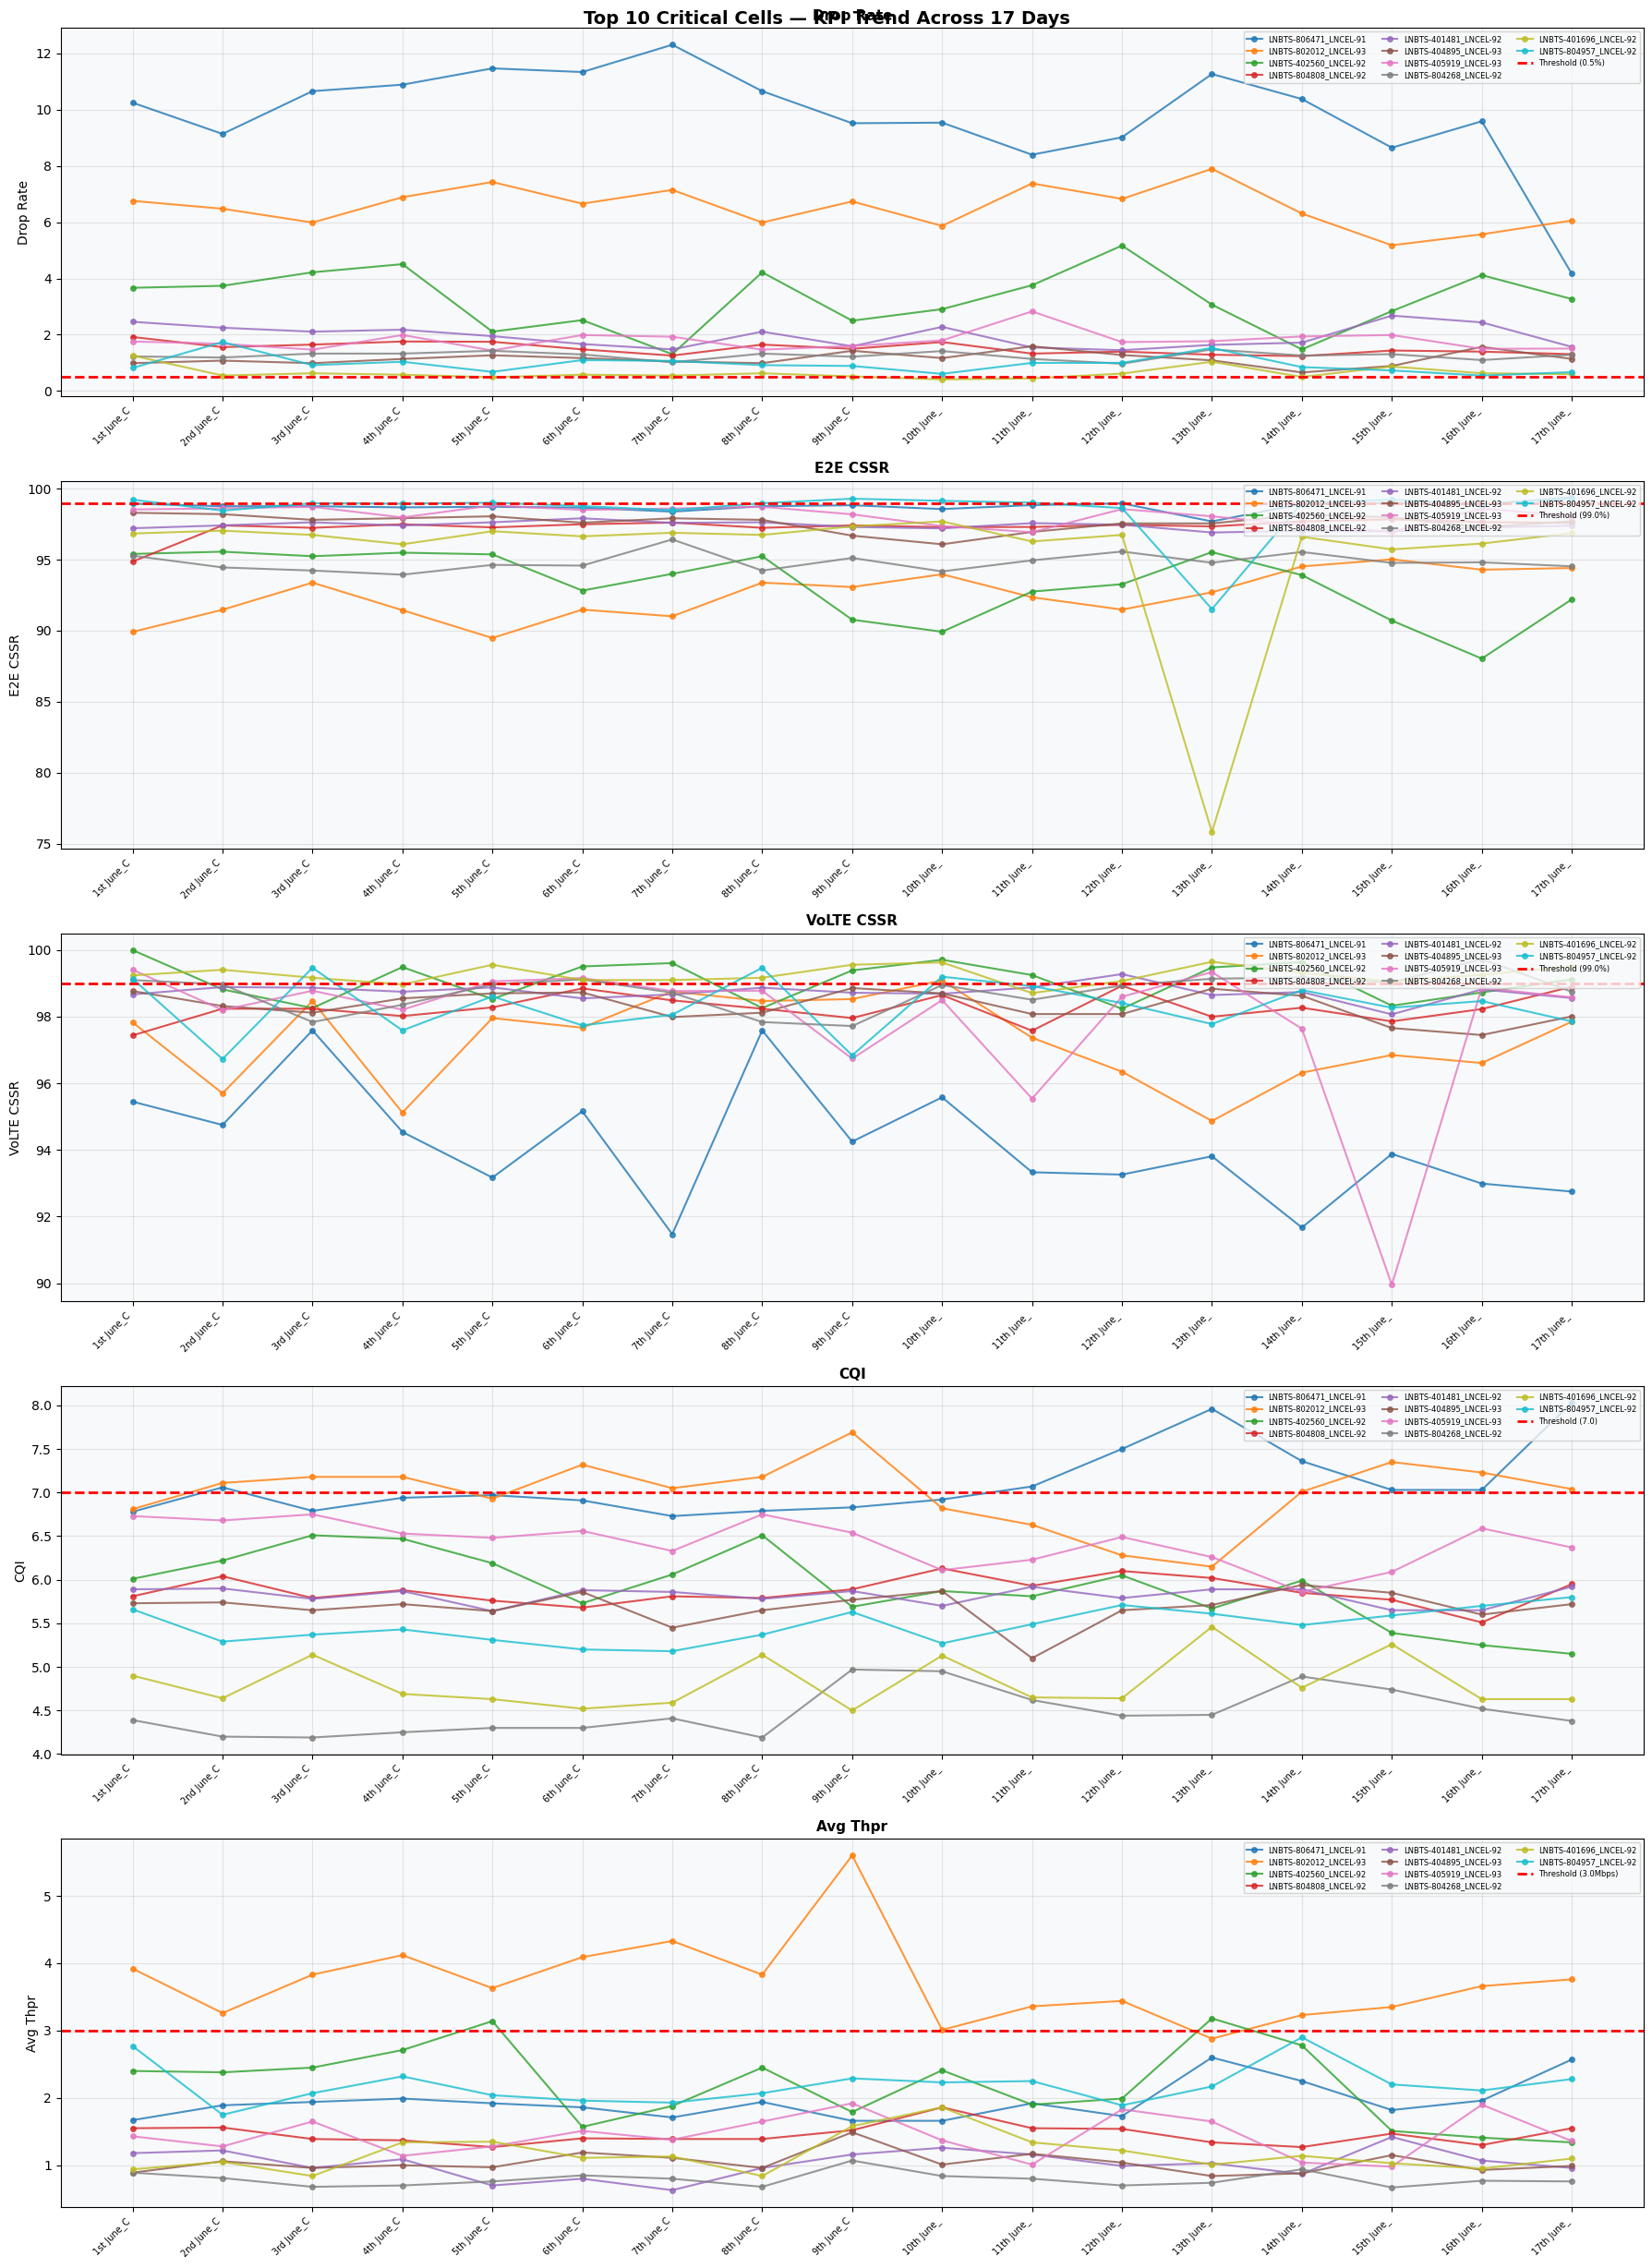

✅ Saved → outputs/viz_critical_cell_trends.png


In [11]:
# Cell 7 – Deep dive into top 10 critical cells
# Shows their KPI values across all 17 days

top10_cells = (
    priority_df.head(10)["Short_Cell"].tolist()
    if "Short_Cell" in priority_df.columns
    else []
)

if not top10_cells:
    # Fallback — compute from rc_df
    top10_cells = (
        rc_df.groupby("Short_Cell")["fail_count"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index.tolist()
    )

fig, axes = plt.subplots(
    len(KPI_CONFIG), 1,
    figsize=(18, 5 * len(KPI_CONFIG))
)
fig.suptitle(
    "Top 10 Critical Cells — KPI Trend Across 17 Days",
    fontsize=14, fontweight="bold"
)

colors_10 = plt.cm.tab10(np.linspace(0, 1, len(top10_cells)))

for ax, cfg in zip(axes, KPI_CONFIG):
    col = cfg["col"]
    if col not in df.columns:
        continue

    for cell, color in zip(top10_cells, colors_10):
        cell_data = (
            df[df["Short_Cell"] == cell]
            .sort_values("Day_Index")
        )
        if cell_data.empty:
            continue
        vals = pd.to_numeric(
            cell_data[col], errors="coerce"
        ).values
        ax.plot(
            cell_data["Day_Index"].values,
            vals,
            marker="o", markersize=4,
            linewidth=1.5, alpha=0.8,
            color=color, label=cell
        )

    ax.axhline(
        cfg["threshold"],
        color="red", linestyle="--",
        linewidth=2,
        label=f"Threshold ({cfg['threshold']}{cfg['unit']})"
    )
    ax.set_xticks(range(len(sheet_names)))
    ax.set_xticklabels(
        [s[:10] for s in sheet_names],
        rotation=45, ha="right", fontsize=7
    )
    ax.set_title(cfg["label"], fontweight="bold", fontsize=11)
    ax.set_ylabel(cfg["label"])
    ax.legend(fontsize=6, loc="upper right",
              ncol=3, bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("../outputs/viz_critical_cell_trends.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/viz_critical_cell_trends.png")

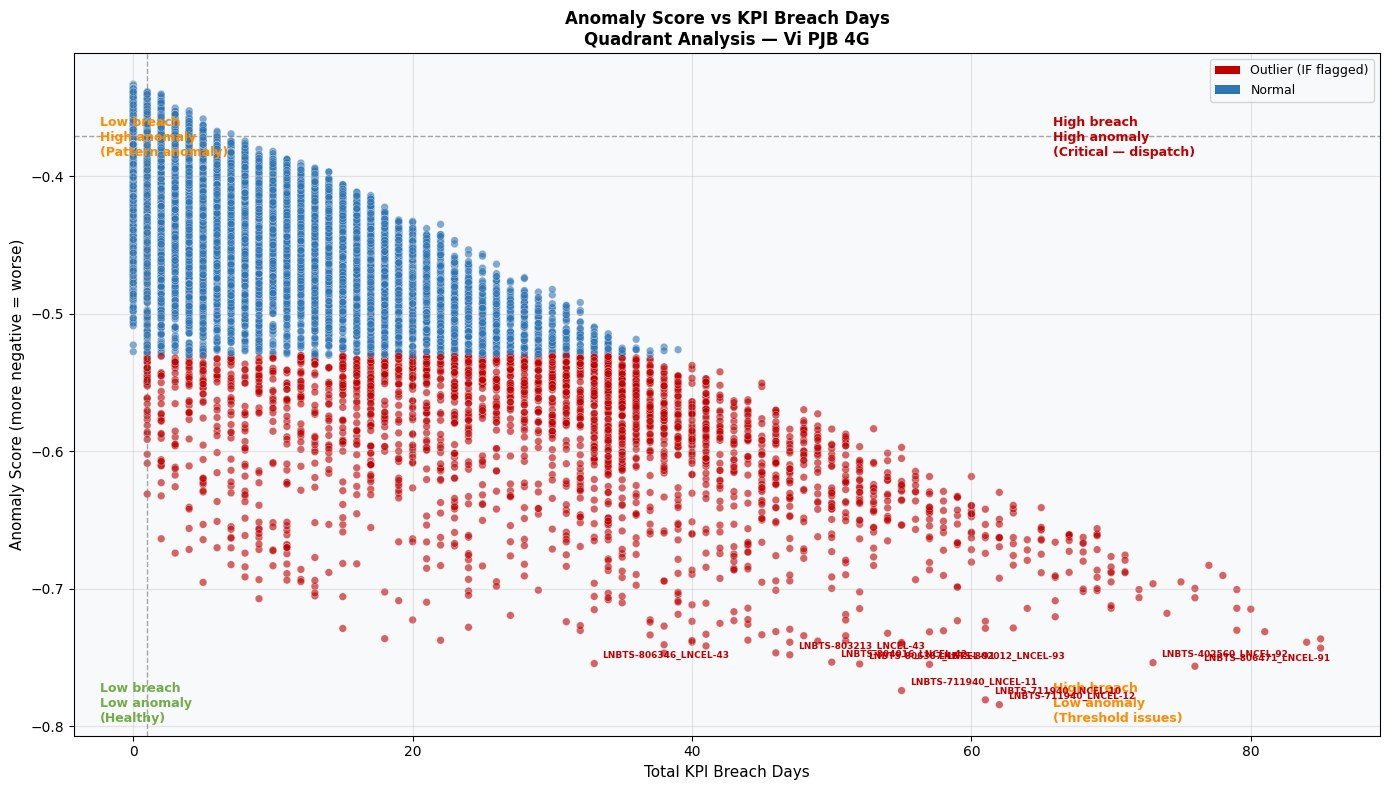

✅ Saved → outputs/viz_quadrant_analysis.png


In [12]:
# Cell 8 – Scatter: anomaly score vs total breach days
# Quadrant analysis — which cells are worst on both metrics

if "anomaly_score" in anomaly_df.columns and \
   "total_breach_days" in anomaly_df.columns:

    plot_df = anomaly_df.copy()
    plot_df["anomaly_score"] = pd.to_numeric(
        plot_df["anomaly_score"], errors="coerce"
    )
    plot_df["total_breach_days"] = pd.to_numeric(
        plot_df["total_breach_days"], errors="coerce"
    )
    plot_df = plot_df.dropna(
        subset=["anomaly_score", "total_breach_days"]
    )

    # Colour by anomaly flag
    colors = plot_df["anomaly_flag"].map(
        {-1: "#C00000", 1: "#2E75B6"}
    ).fillna("#BFBFBF")

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.scatter(
        plot_df["total_breach_days"],
        plot_df["anomaly_score"],
        c=colors, alpha=0.6, s=30,
        edgecolors="white", linewidth=0.3
    )

    # Quadrant lines
    med_breach = plot_df["total_breach_days"].median()
    med_score  = plot_df["anomaly_score"].median()
    ax.axvline(med_breach, color="gray",
               linestyle="--", linewidth=1, alpha=0.7)
    ax.axhline(med_score, color="gray",
               linestyle="--", linewidth=1, alpha=0.7)

    # Quadrant labels
    ax.text(0.02, 0.02,
            "Low breach\nLow anomaly\n(Healthy)",
            transform=ax.transAxes, fontsize=9,
            color="#70AD47", fontweight="bold")
    ax.text(0.75, 0.02,
            "High breach\nLow anomaly\n(Threshold issues)",
            transform=ax.transAxes, fontsize=9,
            color="#FF8C00", fontweight="bold")
    ax.text(0.02, 0.85,
            "Low breach\nHigh anomaly\n(Pattern anomaly)",
            transform=ax.transAxes, fontsize=9,
            color="#FF8C00", fontweight="bold")
    ax.text(0.75, 0.85,
            "High breach\nHigh anomaly\n(Critical — dispatch)",
            transform=ax.transAxes, fontsize=9,
            color="#C00000", fontweight="bold")

    # Label top 10 worst
    worst10 = plot_df.sort_values("anomaly_score").head(10)
    for _, row in worst10.iterrows():
        ax.annotate(
            row["Short_Cell"],
            (row["total_breach_days"], row["anomaly_score"]),
            textcoords="offset points",
            xytext=(6, 4), fontsize=6.5,
            color="#C00000", fontweight="bold"
        )

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#C00000", label="Outlier (IF flagged)"),
        Patch(facecolor="#2E75B6", label="Normal"),
    ]
    ax.legend(handles=legend_elements, fontsize=9)
    ax.set_xlabel("Total KPI Breach Days", fontsize=11)
    ax.set_ylabel("Anomaly Score (more negative = worse)",
                  fontsize=11)
    ax.set_title(
        "Anomaly Score vs KPI Breach Days\n"
        "Quadrant Analysis — Vi PJB 4G",
        fontweight="bold", fontsize=12
    )
    plt.tight_layout()
    plt.savefig("../outputs/viz_quadrant_analysis.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved → outputs/viz_quadrant_analysis.png")

In [13]:
# Cell 9 – Print network health summary card

import re
from collections import Counter

print("=" * 65)
print("  Vi PJB 4G NETWORK HEALTH REPORT — 17-DAY SUMMARY")
print("=" * 65)

total_cells     = df["Short_Cell"].nunique()
total_cell_days = len(df)
days            = df["Day"].nunique()

print(f"\n  Network   : Vodafone Idea (Vi) — Punjab (PJB)")
print(f"  Vendor    : Nokia")
print(f"  Period    : {days} days")
print(f"  Cells     : {total_cells} unique cells")
print(f"  Records   : {total_cell_days:,} cell-day observations")

print(f"\n{'─'*65}")
print("  KPI PERFORMANCE SUMMARY")
print(f"{'─'*65}")
print(f"  {'KPI':<20} {'Mean':>8} {'Threshold':>12} "
      f"{'Breach %':>10} {'Status':>10}")
print(f"  {'─'*60}")

for cfg in KPI_CONFIG:
    col = cfg["col"]
    if col not in df.columns:
        continue
    data = pd.to_numeric(df[col], errors="coerce").dropna()
    mean = data.mean()
    if cfg["direction"] == "high":
        breach_pct = (data > cfg["threshold"]).mean() * 100
        status     = "⚠️  BAD" if mean > cfg["threshold"] else "✅ OK"
    else:
        breach_pct = (data < cfg["threshold"]).mean() * 100
        status     = "⚠️  BAD" if mean < cfg["threshold"] else "✅ OK"
    print(f"  {cfg['label']:<20} {mean:>8.2f} "
          f"{cfg['threshold']:>12} "
          f"{breach_pct:>9.1f}%  {status}")

print(f"\n{'─'*65}")
print("  ANOMALY DETECTION RESULTS")
print(f"{'─'*65}")
if "anomaly_flag" in anomaly_df.columns:
    n_outlier = (anomaly_df["anomaly_flag"] == -1).sum()
    n_normal  = (anomaly_df["anomaly_flag"] ==  1).sum()
    print(f"  Model          : Isolation Forest")
    print(f"  Contamination  : 5%")
    print(f"  Outlier cells  : {n_outlier} ({n_outlier/(n_outlier+n_normal)*100:.1f}%)")
    print(f"  Normal cells   : {n_normal}")

print(f"\n{'─'*65}")
print("  TOP ROOT CAUSES")
print(f"{'─'*65}")
all_rc = []
for rc in rc_df["Root_Cause"]:
    if rc == "Anomaly (score-based)":
        continue
    for part in str(rc).split(","):
        label = re.sub(r'\s*\(.*?\)', '', part).strip()
        if label:
            all_rc.append(label)
rc_counter = Counter(all_rc).most_common(5)
for i, (cause, count) in enumerate(rc_counter, 1):
    print(f"  {i}. {cause:<30} {count:>6,} occurrences")

print(f"\n{'─'*65}")
print("  OUTPUT FILES")
print(f"{'─'*65}")
files = [
    "Daily_Outlier_Cell_Report.xlsx",
    "viz_network_overview.png",
    "viz_breach_heatmap.png",
    "viz_worst_cells_overall.png",
    "viz_critical_cell_trends.png",
    "viz_quadrant_analysis.png",
]
for f in files:
    path   = f"../outputs/{f}"
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"  {exists}  {f}")

print(f"\n{'='*65}")

  Vi PJB 4G NETWORK HEALTH REPORT — 17-DAY SUMMARY

  Network   : Vodafone Idea (Vi) — Punjab (PJB)
  Vendor    : Nokia
  Period    : 17 days
  Cells     : 51359 unique cells
  Records   : 842,125 cell-day observations

─────────────────────────────────────────────────────────────────
  KPI PERFORMANCE SUMMARY
─────────────────────────────────────────────────────────────────
  KPI                      Mean    Threshold   Breach %     Status
  ────────────────────────────────────────────────────────────
  Drop Rate                0.22          0.5       6.2%  ✅ OK
  E2E CSSR                99.56         99.0       8.0%  ✅ OK
  VoLTE CSSR              99.63         99.0       4.2%  ✅ OK
  CQI                      9.61          7.0       2.6%  ✅ OK
  Avg Thpr                10.07          3.0       7.2%  ✅ OK

─────────────────────────────────────────────────────────────────
  ANOMALY DETECTION RESULTS
─────────────────────────────────────────────────────────────────
  Model          : Is